### Step 1: Mount the Google Drive

Remember to use GPU runtime before mounting your Google Drive. (Runtime --> Change runtime type).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 2: Open the project directory

Replace `Your_Dir` with your own path.

In [2]:
# clone the repo into Colab
!rm -rf ECE_C147A_Final
!GIT_LFS_SKIP_SMUDGE=1 git clone https://github.com/DysonLewis/ECE_C147A_Final.git

'''
from google.colab import files
files.upload()
!mv generic.ckpt /content/ECE_C147A_Final/Project/emg2qwerty/models/
'''

Cloning into 'ECE_C147A_Final'...
remote: Enumerating objects: 351, done.
remote: Counting objects: 100% (247/247), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 351 (delta 116), reused 129 (delta 51), pack-reused 104 (from 1)
Receiving objects: 100% (351/351), 33.98 MiB | 24.50 MiB/s, done.
Resolving deltas: 100% (125/125), done.


'\nfrom google.colab import files\nfiles.upload()\n!mv generic.ckpt /content/ECE_C147A_Final/Project/emg2qwerty/models/\n'

### Step 3: Install required packages

After installing them, Colab will require you to restart the session.

In [3]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty

!mkdir data/

!cp /content/drive/MyDrive/data/* /content/ECE_C147A_Final/Project/emg2qwerty/data/

/content/ECE_C147A_Final/Project/emg2qwerty


In [4]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.6/553.6 kB 575.1 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of typer to determine which version is

### Step 4: Start your experiments!

- Remember to download and copy the dataset to this directory: `Your_Dir/emg2qwerty/data`.
- You may now start your experiments with any scripts! Below are examples of single-user training and testing (greedy decoding).
- **There are two ways to track the logs:**
  - 1. Keep `--multirun`, and the logs will not be printed here, but they will be saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/submitit_logs/`.
  - 2. Comment out `--multirun` and the logs will be printed in this notebook, but they will not be saved.

#### Training

- The checkpoints are saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/checkpoints/`.

In [5]:
# ─── Step 1: Delete the old files ────────────────────────────────────────────
import os

files_to_delete = [
    "emg2qwerty/modules.py",
    "emg2qwerty/lightning.py",
    "config/base.yaml",
    "config/model/cnn_ctc.yaml",
    "config/model/rnn_ctc.yaml",
    "config/model/cnn_gru_ctc.yaml",
    "config/model/cnn_lstm_ctc.yaml",
    "config/model/cnn_transformer_ctc.yaml",
    "config/model/rnn_gru_ctc.yaml",
    "config/model/rnn_lstm_ctc.yaml",
    "config/model/rnn_transformer_ctc.yaml",
]

for f in files_to_delete:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted: {f}")
    else:
        print(f"Not found (skipping): {f}")

# ─── Step 2: Upload the zip ───────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()  # upload emg2qwerty_fixes.zip here

# ─── Step 3: Unzip and place files in the correct locations ──────────────────
import zipfile, shutil

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("/tmp/fixes")

# Map extracted paths → destination paths
file_map = {
    "/tmp/fixes/emg2qwerty/modules.py":                       "emg2qwerty/modules.py",
    "/tmp/fixes/emg2qwerty/lightning.py":                     "emg2qwerty/lightning.py",
    "/tmp/fixes/config/base.yaml":                            "config/base.yaml",
    "/tmp/fixes/config/model/cnn_ctc.yaml":                   "config/model/cnn_ctc.yaml",
    "/tmp/fixes/config/model/rnn_ctc.yaml":                   "config/model/rnn_ctc.yaml",
    "/tmp/fixes/config/model/cnn_gru_ctc.yaml":               "config/model/cnn_gru_ctc.yaml",
    "/tmp/fixes/config/model/cnn_lstm_ctc.yaml":              "config/model/cnn_lstm_ctc.yaml",
    "/tmp/fixes/config/model/cnn_transformer_ctc.yaml":       "config/model/cnn_transformer_ctc.yaml",
    "/tmp/fixes/config/model/rnn_gru_ctc.yaml":               "config/model/rnn_gru_ctc.yaml",
    "/tmp/fixes/config/model/rnn_lstm_ctc.yaml":              "config/model/rnn_lstm_ctc.yaml",
    "/tmp/fixes/config/model/rnn_transformer_ctc.yaml":       "config/model/rnn_transformer_ctc.yaml",
}

for src, dst in file_map.items():
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    shutil.copy2(src, dst)
    print(f"Placed: {dst}")

print("All files replaced. You're good to go.")

Not found (skipping): emg2qwerty/modules.py
Not found (skipping): emg2qwerty/lightning.py
Not found (skipping): config/base.yaml
Not found (skipping): config/model/cnn_ctc.yaml
Not found (skipping): config/model/rnn_ctc.yaml
Not found (skipping): config/model/cnn_gru_ctc.yaml
Not found (skipping): config/model/cnn_lstm_ctc.yaml
Not found (skipping): config/model/cnn_transformer_ctc.yaml
Deleted: config/model/rnn_gru_ctc.yaml
Deleted: config/model/rnn_lstm_ctc.yaml
Not found (skipping): config/model/rnn_transformer_ctc.yaml


Saving emg2qwerty_fixes.zip to emg2qwerty_fixes (1).zip
Placed: emg2qwerty/modules.py
Placed: emg2qwerty/lightning.py
Placed: config/base.yaml
Placed: config/model/cnn_ctc.yaml
Placed: config/model/rnn_ctc.yaml
Placed: config/model/cnn_gru_ctc.yaml
Placed: config/model/cnn_lstm_ctc.yaml
Placed: config/model/cnn_transformer_ctc.yaml
Placed: config/model/rnn_gru_ctc.yaml
Placed: config/model/rnn_lstm_ctc.yaml
Placed: config/model/rnn_transformer_ctc.yaml
All files replaced. You're good to go.


In [3]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty
!python -m emg2qwerty.train \
  user="single_user" \
  model=cnn_transformer_ctc \
  transforms=fourier_features \
  dataset.root=data \
  trainer.accelerator=gpu trainer.devices=1 \
  +trainer.max_time="00:00:07:00" \
  batch_size=64 \
  num_workers=8 \
  optimizer.lr=0.0015 \
  +trainer.log_every_n_steps=5
  #--multirun

/content/ECE_C147A_Final/Project/emg2qwerty
[2026-03-09 18:13:45,961][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-

#### Fourier Features Training

The Nyquist verification prints how much signal power would be aliased at each downsample factor.

In [ ]:
from pathlib import Path
import h5py
import numpy as np

data_dir = Path('data')
hdf5_files = list(data_dir.glob('*.hdf5'))

fs = 2000
with h5py.File(hdf5_files[0], 'r') as f:
    emg = f['emg2qwerty']['timeseries']['emg_left'][:10000, 0]

freqs = np.fft.rfftfreq(len(emg), d=1.0 / fs)
psd   = np.abs(np.fft.rfft(emg)) ** 2
total = psd.sum()

semg_pct = 100 * psd[(freqs >= 20) & (freqs <= 500)].sum() / total
print(f'Power in 20-500 Hz sEMG band: {semg_pct:.1f}% of total\n')
print(f'{"Factor":<8} {"Effective fs":<15} {"Aliased power %":<18} {"Status"}')
print('-' * 58)
for factor in [1, 2, 4, 8]:
    eff_fs  = fs // factor
    aliased = 100 * psd[freqs > (eff_fs / 2)].sum() / total
    status  = 'safe' if factor <= 2 else 'violates Nyquist'
    print(f'{factor:<8} {eff_fs:<15} {aliased:<18.2f} {status}')

data_fourier ready: 18 sessions linked
Power in 20-500 Hz sEMG band: 92.7% of total

Factor   Effective fs    Aliased power %    Status
----------------------------------------------------------
1        2000            0.00               safe
2        1000            7.34               safe
4        500             22.82              violates Nyquist
8        250             49.16              violates Nyquist


##TESTING CONFIGS

#CNN

In [6]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty
import time, json, threading, subprocess
import psutil
from pathlib import Path

def sample_memory(samples, stop_event, interval=60):
    while not stop_event.is_set():
        ram_gb = psutil.virtual_memory().used / 1e9
        try:
            smi = subprocess.check_output(
                ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
                text=True
            )
            vram_mb = int(smi.strip())
        except Exception:
            vram_mb = None
        samples.append({
            "elapsed_min": round((time.time() - samples[0]["t0"]) / 60, 2),
            "ram_gb": round(ram_gb, 2),
            "vram_mb": vram_mb,
            "t0": samples[0]["t0"],
        })
        stop_event.wait(interval)

configs = [
    {"name": "cnn_ctc",             "model": "cnn_ctc"},
    {"name": "cnn_gru_ctc",         "model": "cnn_gru_ctc"},
    {"name": "cnn_lstm_ctc",        "model": "cnn_lstm_ctc"},
    {"name": "cnn_transformer_ctc", "model": "cnn_transformer_ctc"},
]

results = {}

for cfg in configs:
    print(f"\n{'='*60}\nRunning: {cfg['name']}\n{'='*60}")
    start = time.time()

    samples = [{"elapsed_min": 0, "ram_gb": 0, "vram_mb": 0, "t0": start}]
    stop_event = threading.Event()
    monitor = threading.Thread(target=sample_memory, args=(samples, stop_event), daemon=True)
    monitor.start()

    !python -m emg2qwerty.train \
        user="single_user" \
        model={cfg['model']} \
        transforms=fourier_features \
        dataset.root=data \
        trainer.accelerator=gpu trainer.devices=1 \
        +trainer.max_time="00:00:45:00" \
        batch_size=64 \
        num_workers=8 \
        optimizer.lr=0.0015 \
        +trainer.log_every_n_steps=5 \
        "hydra.run.dir=logs/{cfg['name']}"

    stop_event.set()
    elapsed = time.time() - start

    valid = [s for s in samples if s["elapsed_min"] > 0]
    midpoint = min(valid, key=lambda s: abs(s["elapsed_min"] - 20)) if valid else {}

    results[cfg['name']] = {
        "config": cfg,
        "time_min": round(elapsed / 60, 2),
        "memory_at_20min": {
            "elapsed_min": midpoint.get("elapsed_min"),
            "ram_gb":      midpoint.get("ram_gb"),
            "vram_mb":     midpoint.get("vram_mb"),
        },
    }
    print(f"  Done in {elapsed/60:.2f} min | RAM: {midpoint.get('ram_gb')}GB | VRAM: {midpoint.get('vram_mb')}MB")

with open("arch_sweep_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nResults saved to arch_sweep_results.json")

/content/ECE_C147A_Final/Project/emg2qwerty

Running: cnn_ctc
[2026-03-09 18:28:11,501][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-16226799

In [ ]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty
import time, json, threading, subprocess
import psutil
from pathlib import Path

def sample_memory(samples, stop_event, interval=60):
    while not stop_event.is_set():
        ram_gb = psutil.virtual_memory().used / 1e9
        try:
            smi = subprocess.check_output(
                ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
                text=True
            )
            vram_mb = int(smi.strip())
        except Exception:
            vram_mb = None
        samples.append({
            "elapsed_min": round((time.time() - samples[0]["t0"]) / 60, 2),
            "ram_gb": round(ram_gb, 2),
            "vram_mb": vram_mb,
            "t0": samples[0]["t0"],
        })
        stop_event.wait(interval)

configs = [
    {"name": "rnn_ctc",             "model": "rnn_ctc"},
    {"name": "rnn_gru_ctc",         "model": "rnn_gru_ctc"},
    {"name": "rnn_lstm_ctc",        "model": "rnn_lstm_ctc"},
    {"name": "rnn_transformer_ctc", "model": "rnn_transformer_ctc"},
]

results = {}

for cfg in configs:
    print(f"\n{'='*60}\nRunning: {cfg['name']}\n{'='*60}")
    start = time.time()

    samples = [{"elapsed_min": 0, "ram_gb": 0, "vram_mb": 0, "t0": start}]
    stop_event = threading.Event()
    monitor = threading.Thread(target=sample_memory, args=(samples, stop_event), daemon=True)
    monitor.start()

    !python -m emg2qwerty.train \
        user="single_user" \
        model={cfg['model']} \
        transforms=fourier_features \
        dataset.root=data \
        trainer.accelerator=gpu trainer.devices=1 \
        +trainer.max_time="00:00:45:00" \
        batch_size=64 \
        num_workers=8 \
        optimizer.lr=0.0015 \
        +trainer.log_every_n_steps=5 \
        "hydra.run.dir=logs/{cfg['name']}"

    stop_event.set()
    elapsed = time.time() - start

    valid = [s for s in samples if s["elapsed_min"] > 0]
    midpoint = min(valid, key=lambda s: abs(s["elapsed_min"] - 20)) if valid else {}

    results[cfg['name']] = {
        "config": cfg,
        "time_min": round(elapsed / 60, 2),
        "memory_at_20min": {
            "elapsed_min": midpoint.get("elapsed_min"),
            "ram_gb":      midpoint.get("ram_gb"),
            "vram_mb":     midpoint.get("vram_mb"),
        },
    }
    print(f"  Done in {elapsed/60:.2f} min | RAM: {midpoint.get('ram_gb')}GB | VRAM: {midpoint.get('vram_mb')}MB")

with open("arch_sweep_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nResults saved to arch_sweep_results.json")

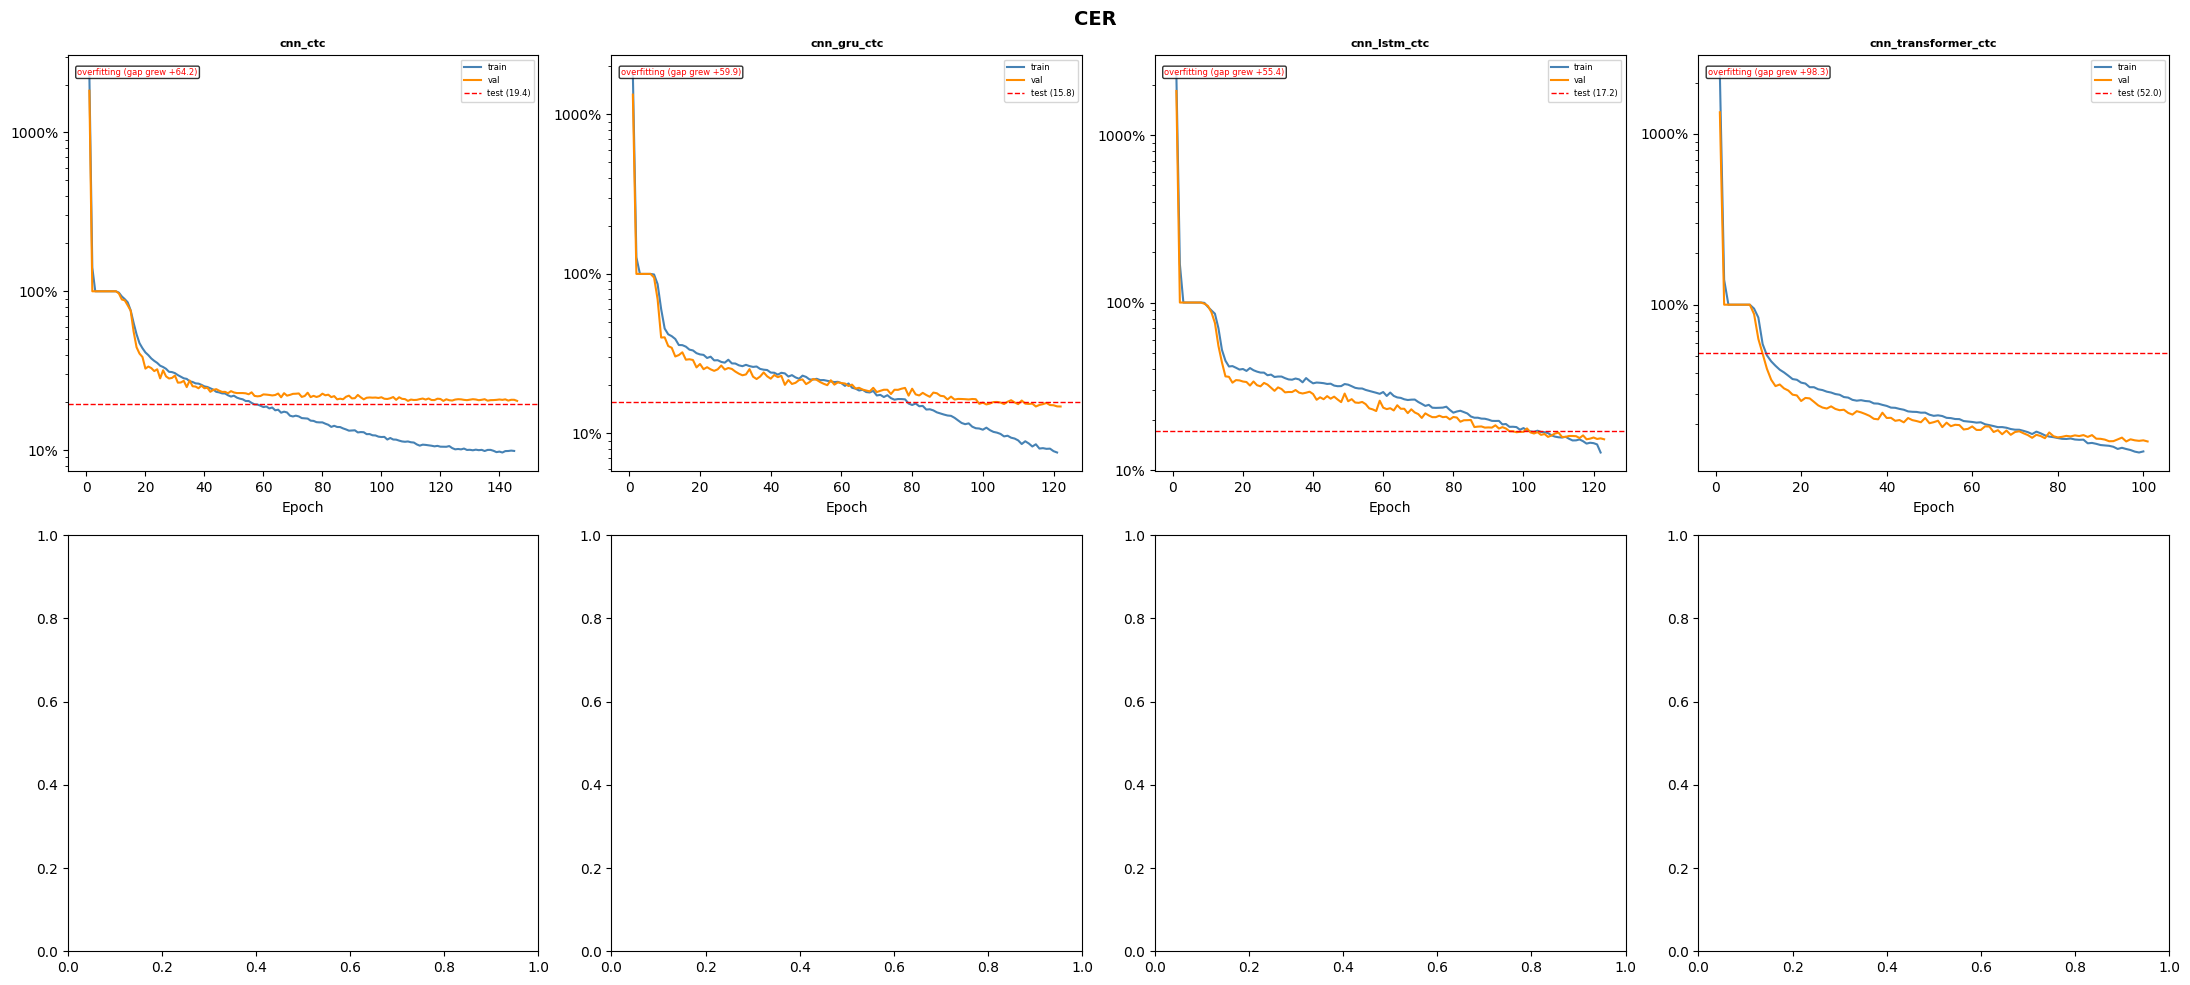

Saved arch_sweep_CER.png


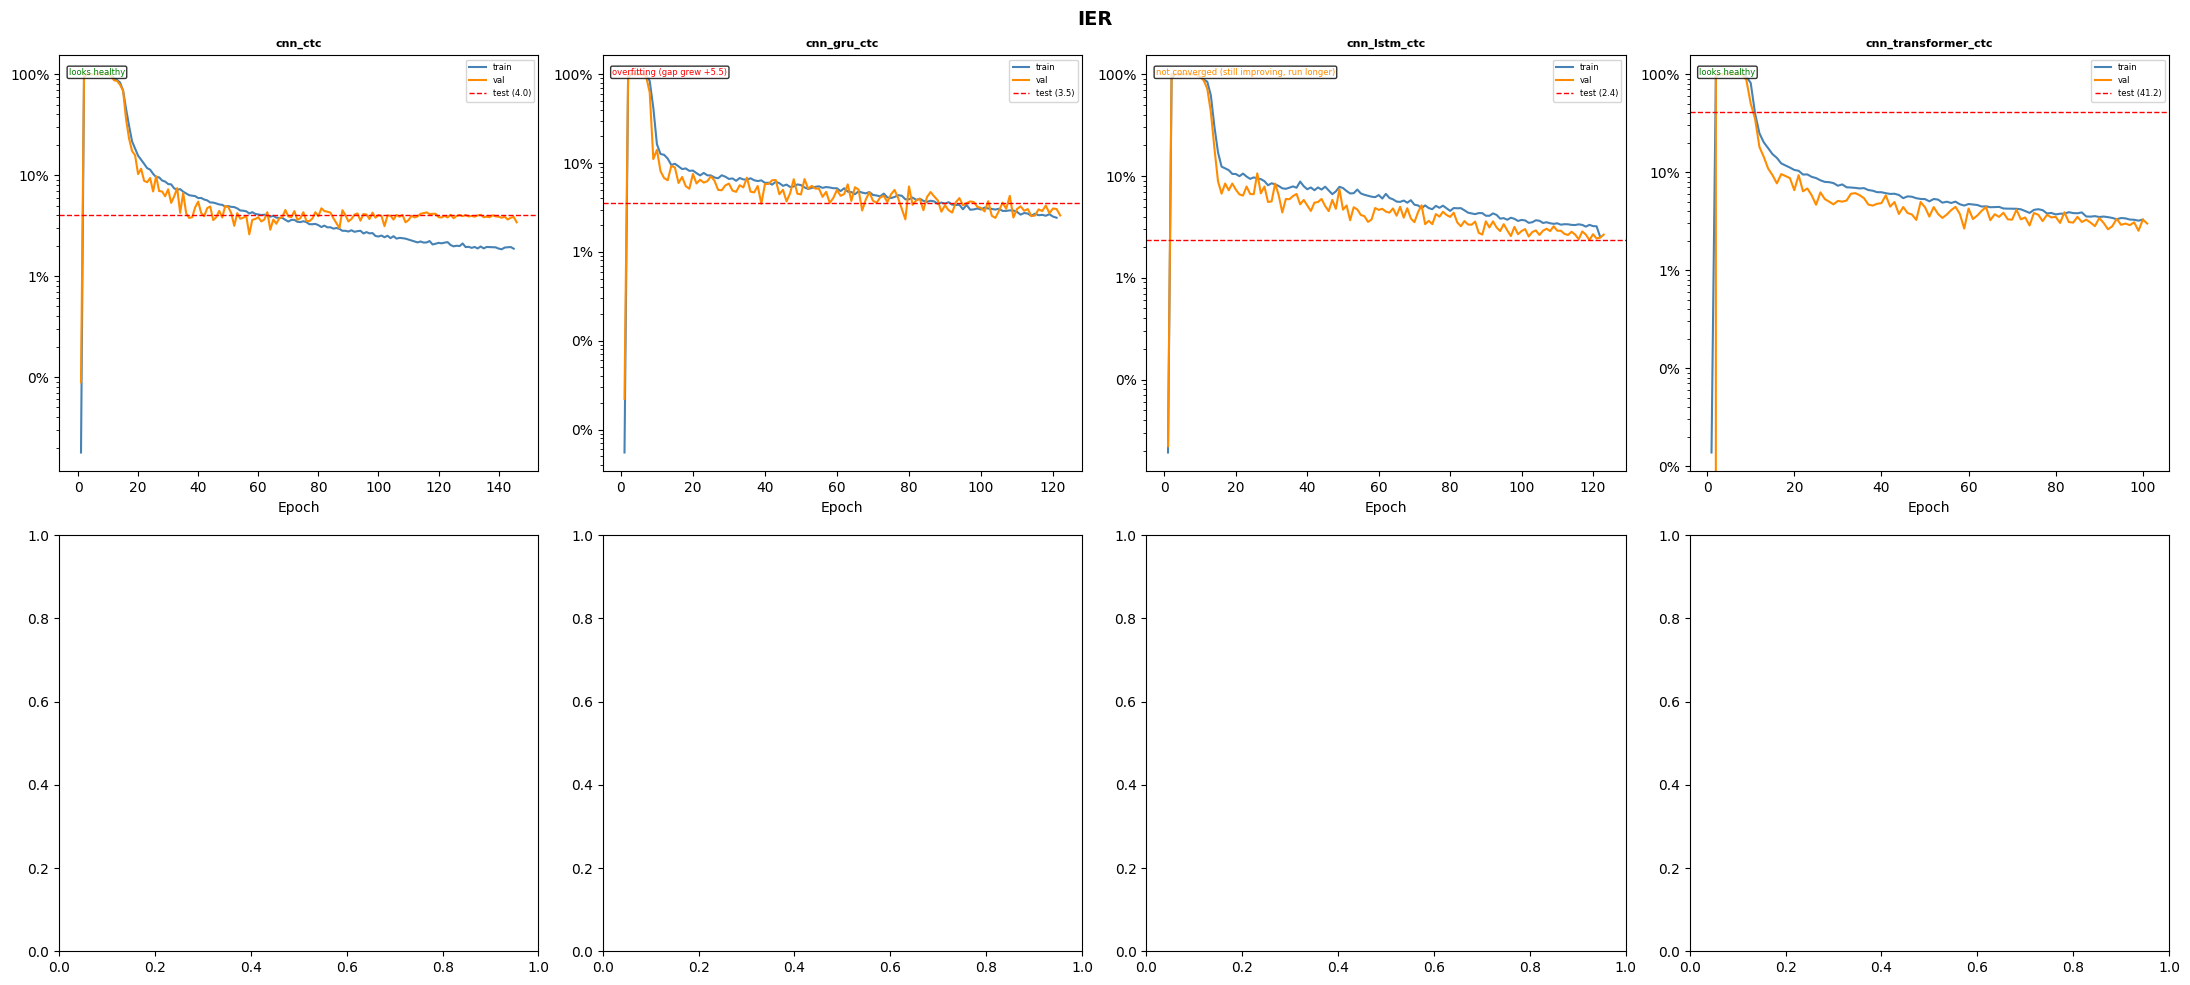

Saved arch_sweep_IER.png


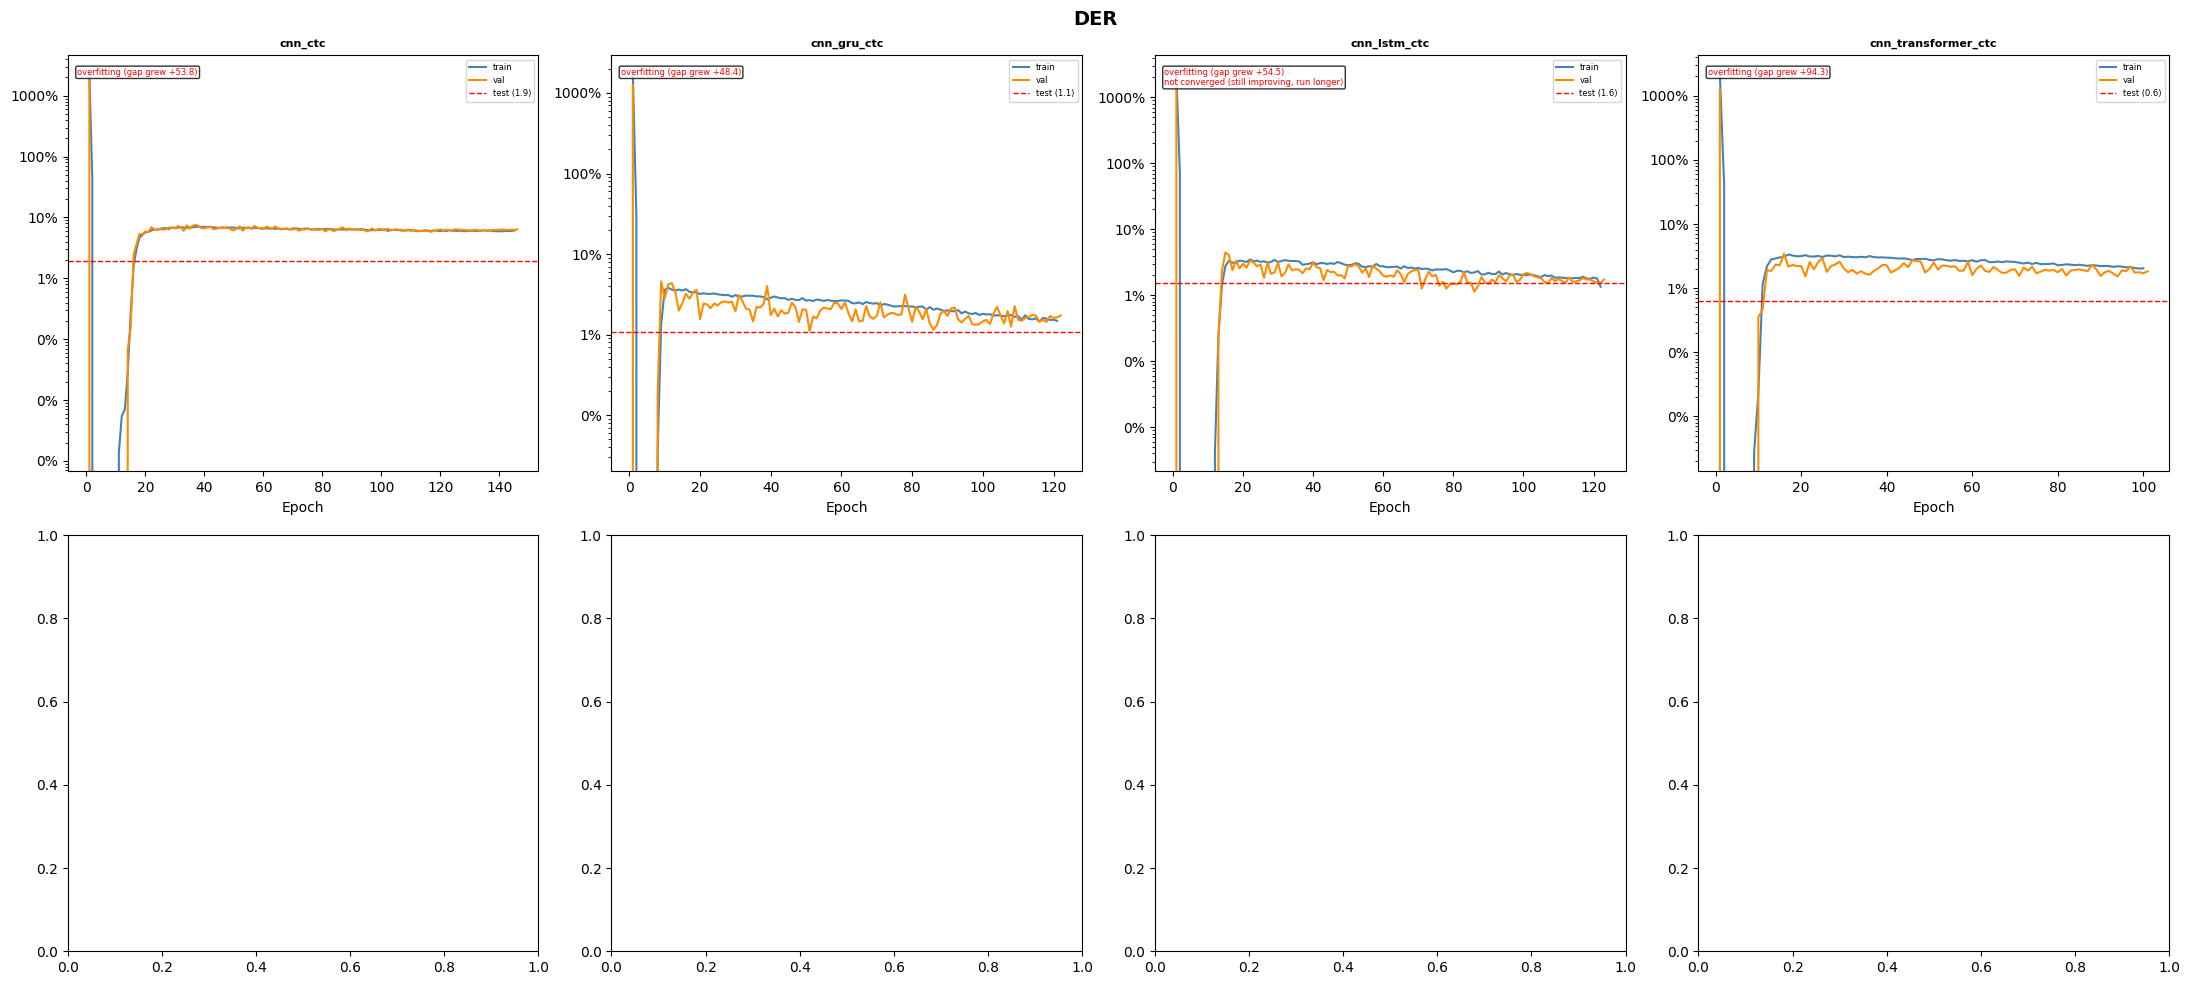

Saved arch_sweep_DER.png


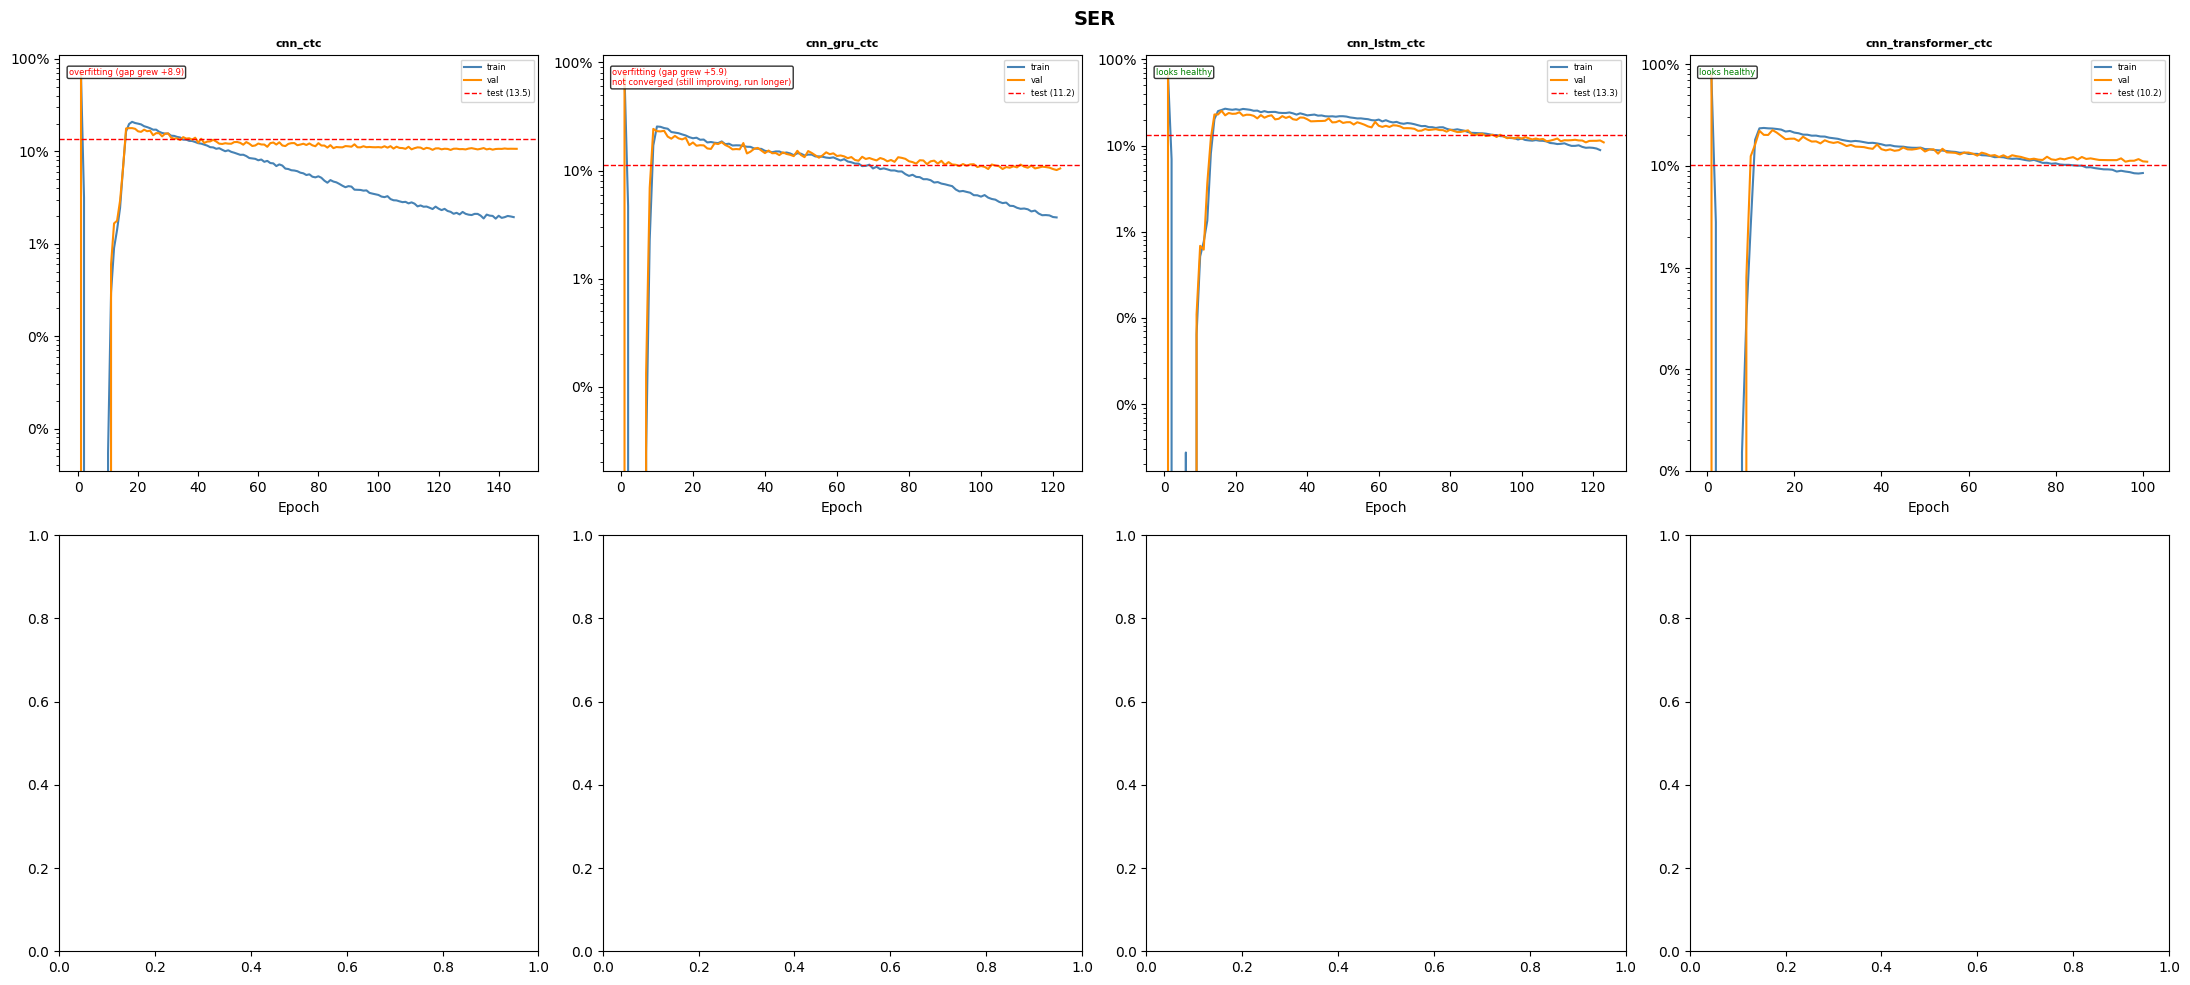

Saved arch_sweep_SER.png


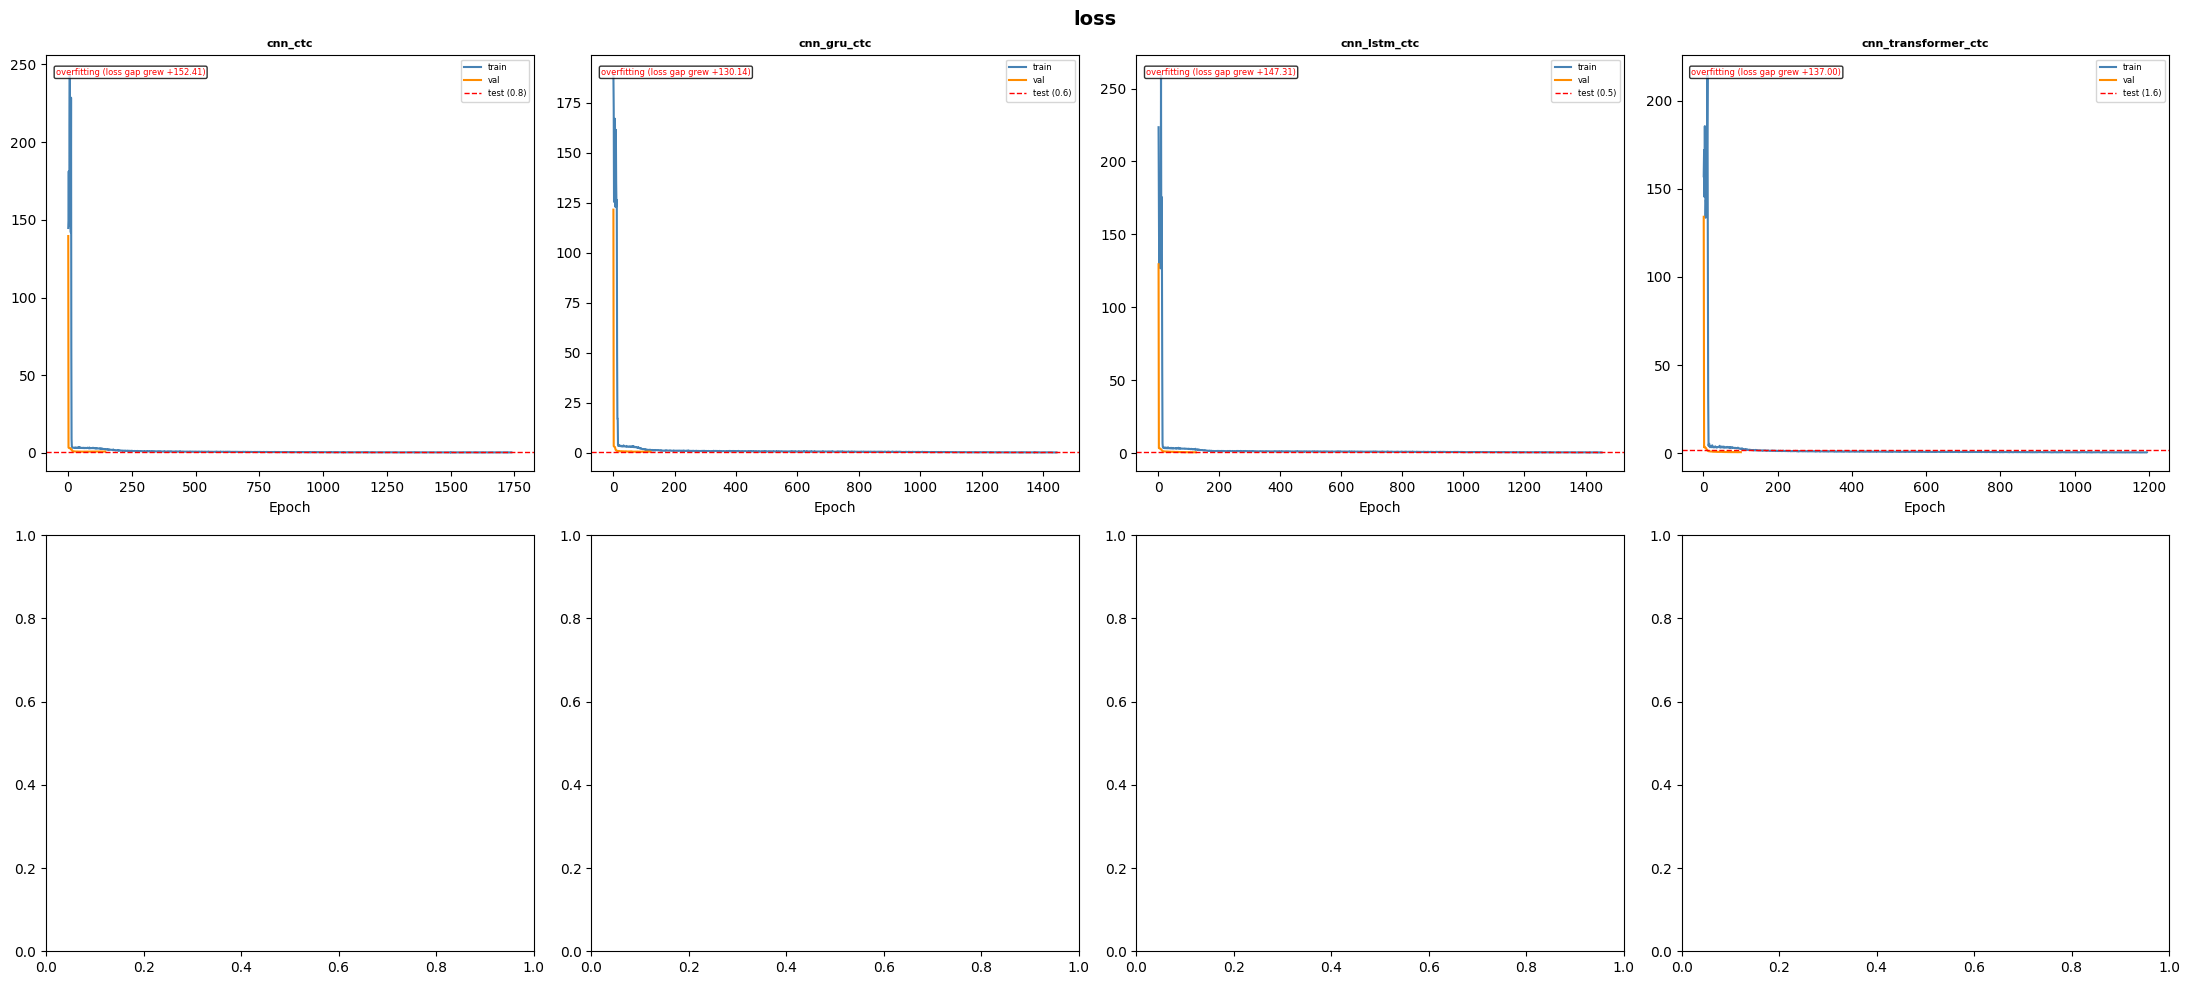

Saved arch_sweep_loss.png

Final Metrics Summary

cnn_ctc
  Metric          Train        Val       Test
  ----------------------------------------
  CER              9.89      20.43      19.43
  IER              1.87       3.41       4.00
  DER              6.08       6.36       1.92
  SER              1.94      10.66      13.51
  loss             0.37       0.90       0.81

cnn_gru_ctc
  Metric          Train        Val       Test
  ----------------------------------------
  CER              7.59      14.75      15.82
  IER              2.42       2.57       3.52
  DER              1.49       1.73       1.08
  SER              3.69      10.46      11.22
  loss             0.24       0.59       0.63

cnn_lstm_ctc
  Metric          Train        Val       Test
  ----------------------------------------
  CER             12.73      15.26      17.18
  IER              2.53       2.66       2.36
  DER              1.34       1.73       1.56
  SER              8.85      10.88      13.27
  lo

In [31]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

configs = [
    "cnn_ctc",
    "cnn_gru_ctc",
    "cnn_lstm_ctc",
    "cnn_transformer_ctc",
]
base = Path("/content/ECE_C147A_Final/Project/emg2qwerty/logs")

results = {}
for name in configs:
    log_dir = base / name / "lightning_logs" / "version_0"
    ea = EventAccumulator(str(log_dir))
    ea.Reload()

    def get_values(tag):
        return [{"step": e.step, "value": e.value} for e in ea.Scalars(tag)]

    results[name] = {
        "train": {t.split("/")[1]: get_values(t) for t in ea.Tags()["scalars"] if t.startswith("train/")},
        "val":   {t.split("/")[1]: get_values(t) for t in ea.Tags()["scalars"] if t.startswith("val/")},
        "test":  {t.split("/")[1]: get_values(t) for t in ea.Tags()["scalars"] if t.startswith("test/")},
    }

with open("arch_sweep_results.json", "w") as f:
    json.dump(results, f, indent=2)

def diagnose(train_vals, val_vals, metric):
    issues = []
    if len(train_vals) < 5 or len(val_vals) < 5:
        return ["insufficient data"]

    train   = np.array(train_vals)
    val     = np.array(val_vals)
    min_len = min(len(train), len(val))
    train   = train[:min_len]
    val     = val[:min_len]
    gap     = val - train

    if metric != "loss":
        late_gap  = gap[-10:].mean()
        early_gap = gap[:10].mean()
        if late_gap > early_gap + 5:
            issues.append(f"overfitting (gap grew +{late_gap - early_gap:.1f})")
    else:
        late_gap  = gap[-10:].mean()
        early_gap = gap[:10].mean()
        if late_gap > early_gap + 0.1:
            issues.append(f"overfitting (loss gap grew +{late_gap - early_gap:.2f})")

    if metric == "CER":
        if val[-1] > 40 and (val[-10] - val[-1]) > 1:
            issues.append(f"underfitting (val CER still {val[-1]:.1f}% and declining)")
        elif val[-1] > 40:
            issues.append(f"high CER plateau ({val[-1]:.1f}%) - may need architecture change")

    if (val[-10] - val[-1]) / (abs(val[-1]) + 1e-6) > 0.05:
        issues.append("not converged (still improving, run longer)")

    if len(val) > 20:
        mid_improvement = val[len(val)//2] - val[-1]
        if abs(mid_improvement) < 0.5 and metric == "CER":
            issues.append(f"plateaued early at epoch ~{len(val)//2}")

    return issues if issues else ["looks healthy"]

metrics = ["CER", "IER", "DER", "SER", "loss"]

# 4 wide x 2 tall per metric
for metric in metrics:
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    fig.suptitle(metric, fontsize=14, fontweight="bold")
    axes_flat = axes.flatten()

    for col, name in enumerate(configs):
        ax = axes_flat[col]

        for phase, color in [("train", "steelblue"), ("val", "darkorange")]:
            data = results[name][phase].get(metric, [])
            if not data:
                continue
            values = np.array([d["value"] for d in data])
            epochs = np.arange(1, len(values) + 1)
            ax.plot(epochs, values, label=phase, color=color, linewidth=1.5)

        test_data = results[name]["test"].get(metric, [])
        if test_data:
            ax.axhline(test_data[-1]["value"], color="red", linestyle="--", linewidth=1,
                       label=f"test ({test_data[-1]['value']:.1f})")

        ax.set_title(name, fontsize=8, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.legend(fontsize=6)

        if metric != "loss":
            ax.set_yscale("log")
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))

        train_vals = [d["value"] for d in results[name]["train"].get(metric, [])]
        val_vals   = [d["value"] for d in results[name]["val"].get(metric, [])]
        if train_vals and val_vals:
            issues = diagnose(train_vals, val_vals, metric)
            ann_color = "red" if any(k in i for i in issues for k in ["overfitting", "high CER", "underfitting"]) else \
                        "darkorange" if any("converged" in i or "plateaued" in i for i in issues) else "green"
            ax.annotate("\n".join(issues), xy=(0.02, 0.97), xycoords="axes fraction",
                        fontsize=6, va="top", color=ann_color,
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))

    plt.tight_layout()
    fname = f"arch_sweep_{metric}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved {fname}")

print("\nFinal Metrics Summary")
print("=" * 70)
for name in configs:
    print(f"\n{name}")
    print(f"  {'Metric':<10} {'Train':>10} {'Val':>10} {'Test':>10}")
    print(f"  {'-'*40}")
    for metric in metrics:
        train_val = results[name]["train"].get(metric, [])
        val_val   = results[name]["val"].get(metric, [])
        test_val  = results[name]["test"].get(metric, [])
        t  = f"{train_val[-1]['value']:.2f}" if train_val else "N/A"
        v  = f"{val_val[-1]['value']:.2f}"   if val_val   else "N/A"
        te = f"{test_val[-1]['value']:.2f}"  if test_val  else "N/A"
        print(f"  {metric:<10} {t:>10} {v:>10} {te:>10}")

In [16]:
import subprocess, sys

result = subprocess.run([
    sys.executable, "-m", "emg2qwerty.train",
    "train=False",
    f"checkpoint='{CHECKPOINT}'",
    f"model={MODEL_NAME}",
    "decoder=ctc_beam",
    "decoder.beam_size=5",
    "decoder.lm_path=null",
], capture_output=True, text=True, cwd="/content/ECE_C147A_Final/Project/emg2qwerty")

print(result.stdout[-2000:])
print(result.stderr[-2000:])

 ?it/s]
Validation DataLoader 0: 100%|██████████| 7/7 [00:49<00:00,  7.13s/it]
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃  Runningstage.validating  ┃                           ┃
┃          metric           ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val/CER          │           100.0           │
│          val/DER          │            0.0            │
│          val/IER          │           100.0           │
│          val/SER          │            0.0            │
│         val/loss          │    16.371416091918945     │
└───────────────────────────┴───────────────────────────┘

Testing: 0it [00:00, ?it/s]
Testing DataLoader 0: 100%|██████████| 1/1 [00:58<00:00, 58.56s/it]
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   Runningstage.testing    ┃                           ┃
┃          metric           ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         te

In [14]:
import itertools
import re
import subprocess
import sys
import json
import time
import pandas as pd
import glob

CHECKPOINT_DIR = "/content/ECE_C147A_Final/Project/emg2qwerty/logs"
MODEL_NAME = "cnn_gru_ctc"
ckpt_files = glob.glob(f"{CHECKPOINT_DIR}/{MODEL_NAME}/checkpoints/*.ckpt")
CHECKPOINT = next(f for f in ckpt_files if "last" not in f)
print(f"Using checkpoint: {CHECKPOINT}")

LM_WEIGHTS      = [0.5, 2.0]
INSERTION_BONUS = [0.5, 2.0]

combos = list(itertools.product(LM_WEIGHTS, INSERTION_BONUS))
total = len(combos)
print(f"{total} combinations queued for {MODEL_NAME}")

def extract(combined, key):
    m = re.search(rf"'{re.escape(key)}':\s*([\d.]+)", combined)
    return float(m.group(1)) if m else None

rows = []
sweep_start = time.time()

for i, (lm_weight, insertion_bonus) in enumerate(combos):
    run_start = time.time()
    elapsed   = run_start - sweep_start
    avg_time  = elapsed / i if i > 0 else 0
    eta       = avg_time * (total - i)

    print(f"\n[{i+1}/{total}]  lm_weight={lm_weight}  insertion_bonus={insertion_bonus}")
    if i > 0:
        print(f"  elapsed={elapsed/60:.1f}min  eta={eta/60:.1f}min  avg/run={avg_time:.0f}s")

    result = subprocess.run([
        sys.executable, "-m", "emg2qwerty.train",
        "train=False",
        f"checkpoint='{CHECKPOINT}'",
        f"model={MODEL_NAME}",
        "decoder=ctc_beam",
        f"decoder.beam_size=2",
        f"decoder.lm_weight={lm_weight}",
        f"decoder.insertion_bonus={insertion_bonus}",
    ], capture_output=True, text=True, cwd="/content/ECE_C147A_Final/Project/emg2qwerty")

    run_time = time.time() - run_start
    combined = result.stdout + result.stderr
    val_cer  = extract(combined, "val/CER")
    test_cer = extract(combined, "test/CER")

    if val_cer is None:
        print(f"  FAILED ({run_time:.0f}s)")
        print(combined[-1000:])
        continue

    print(f"  val CER={val_cer:.2f}  test CER={test_cer:.2f}  ({run_time:.0f}s)")

    # show best so far
    rows.append({
        "lm_weight": lm_weight,
        "insertion_bonus": insertion_bonus,
        "val_CER": val_cer,
        "test_CER": test_cer,
    })
    best_so_far = min(rows, key=lambda x: x["val_CER"])
    print(f"  best so far: lm_weight={best_so_far['lm_weight']}  insertion_bonus={best_so_far['insertion_bonus']}  val CER={best_so_far['val_CER']:.2f}")

print(f"\nSweep complete in {(time.time() - sweep_start)/60:.1f}min")

if not rows:
    print("All runs failed.")
else:
    df = pd.DataFrame(rows).sort_values("val_CER")
    print("\n")
    print(df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

    best = df.iloc[0]
    print(f"\nBest: lm_weight={best['lm_weight']}  insertion_bonus={best['insertion_bonus']}")
    print(f"  val CER={best['val_CER']:.2f}  test CER={best['test_CER']:.2f}")

    with open(f"lm_sweep_{MODEL_NAME}.json", "w") as f:
        json.dump(rows, f, indent=2)

Using checkpoint: /content/ECE_C147A_Final/Project/emg2qwerty/logs/cnn_gru_ctc/checkpoints/epoch=114-step=6900.ckpt
4 combinations queued for cnn_gru_ctc

[1/4]  lm_weight=0.5  insertion_bonus=0.5
  val CER=100.00  test CER=100.00  (105s)
  best so far: lm_weight=0.5  insertion_bonus=0.5  val CER=100.00

[2/4]  lm_weight=0.5  insertion_bonus=2.0
  elapsed=1.7min  eta=5.2min  avg/run=105s
  val CER=100.00  test CER=100.00  (105s)
  best so far: lm_weight=0.5  insertion_bonus=0.5  val CER=100.00

[3/4]  lm_weight=2.0  insertion_bonus=0.5
  elapsed=3.5min  eta=3.5min  avg/run=105s
  val CER=100.00  test CER=100.00  (103s)
  best so far: lm_weight=0.5  insertion_bonus=0.5  val CER=100.00

[4/4]  lm_weight=2.0  insertion_bonus=2.0
  elapsed=5.2min  eta=1.7min  avg/run=104s
  val CER=100.00  test CER=100.00  (103s)
  best so far: lm_weight=0.5  insertion_bonus=0.5  val CER=100.00

Sweep complete in 6.9min


 lm_weight  insertion_bonus  val_CER  test_CER
      0.50             0.50   100.00  

#### Testing:

- Replace `Your_Path_to_Checkpoint` with your checkpoint path.

In [21]:
import os
os.environ["HYDRA_FULL_ERROR"] = "1"

In [22]:
import torch

ckpt = torch.load(
    "/content/ECE_C147A_Final/Project/emg2qwerty/logs/cnn_ctc/checkpoints/epoch=108-step=6540.ckpt",
    map_location="cpu"
)
print(ckpt.keys())
print("\nhparams:", ckpt.get("hyper_parameters", {}).keys())
print("\nfirst few state_dict keys:")
for k in list(ckpt["state_dict"].keys())[:5]:
    print(" ", k)

dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters'])

hparams: dict_keys(['in_features', 'mlp_features', 'optimizer', 'lr_scheduler', 'decoder', 'cnn_channels', 'cnn_kernel_size', 'num_cnn_layers', 'dropout'])

first few state_dict keys:
  spec_norm.batch_norm.weight
  spec_norm.batch_norm.bias
  spec_norm.batch_norm.running_mean
  spec_norm.batch_norm.running_var
  spec_norm.batch_norm.num_batches_tracked


In [36]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty
!python -m emg2qwerty.train \
  user=single_user \
  "checkpoint='/content/ECE_C147A_Final/Project/emg2qwerty/logs/cnn_lstm_ctc/checkpoints/epoch=117-step=7080.ckpt'" \
  model=cnn_lstm_ctc \
  transforms=fourier_features \
  train=false \
  trainer.accelerator=gpu \
  decoder=ctc_greedy

!python -m emg2qwerty.train \
  user=single_user \
  "checkpoint='/content/ECE_C147A_Final/Project/emg2qwerty/logs/cnn_lstm_ctc/checkpoints/epoch=117-step=7080.ckpt'" \
  model=cnn_lstm_ctc \
  transforms=fourier_features \
  train=false \
  trainer.accelerator=gpu \
  decoder=ctc_beam \
  decoder.beam_size=20

/content/ECE_C147A_Final/Project/emg2qwerty
[2026-03-09 23:29:19,972][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-